# Calculate the spatial gradient of a field on the mesh

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**


In [1]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace

scalarSpace = getFELiCSSpace(mesh, order=2, dim=1)
vectorSpace = getFELiCSSpace(mesh, order=2, dim=2)

from FELiCS.Fields.Field import Field

phi = Field(vectorSpace, mesh=mesh)
phi.importH5("function_values_2d")
vorticitySol = Field(scalarSpace, mesh=mesh)
vorticitySol.importH5("vorticity_solution")


fatal: not a git repository: '/home/frederic/miniforge3/envs/felics2025-env/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 11833 nodes and 23664 elements


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


**Step 2: Define the gradient Expression and evaluate it on the Field**

We now want to calculate the gradient of our scalar quantity using the `getGradient()` method of our Field class. This method returns a Field.
To verify the solution we also calculate the gradient manually.

In [2]:
import numpy as np

vorticity = phi.getVorticityField()

# print(cg[0].getListOfSingleFields())
# print(cg[0].getListOfSingleFields()[1].getCoefficientArray())
# print(cg[1].getListOfSingleFields()[0].getCoefficientArray())


print(vorticity.getCoefficientArray())
print(vorticitySol.getCoefficientArray())
print(np.linalg.norm(vorticity.getCoefficientArray() - vorticitySol.getCoefficientArray()))

[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[ 3.07787311e-15+0.j  3.07179963e-15+0.j  5.77189261e-01+0.j ...
 -2.88900182e-01+0.j -3.94719240e-01+0.j -0.00000000e+00+0.j]
1359.9788917758663


[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
0j
0j


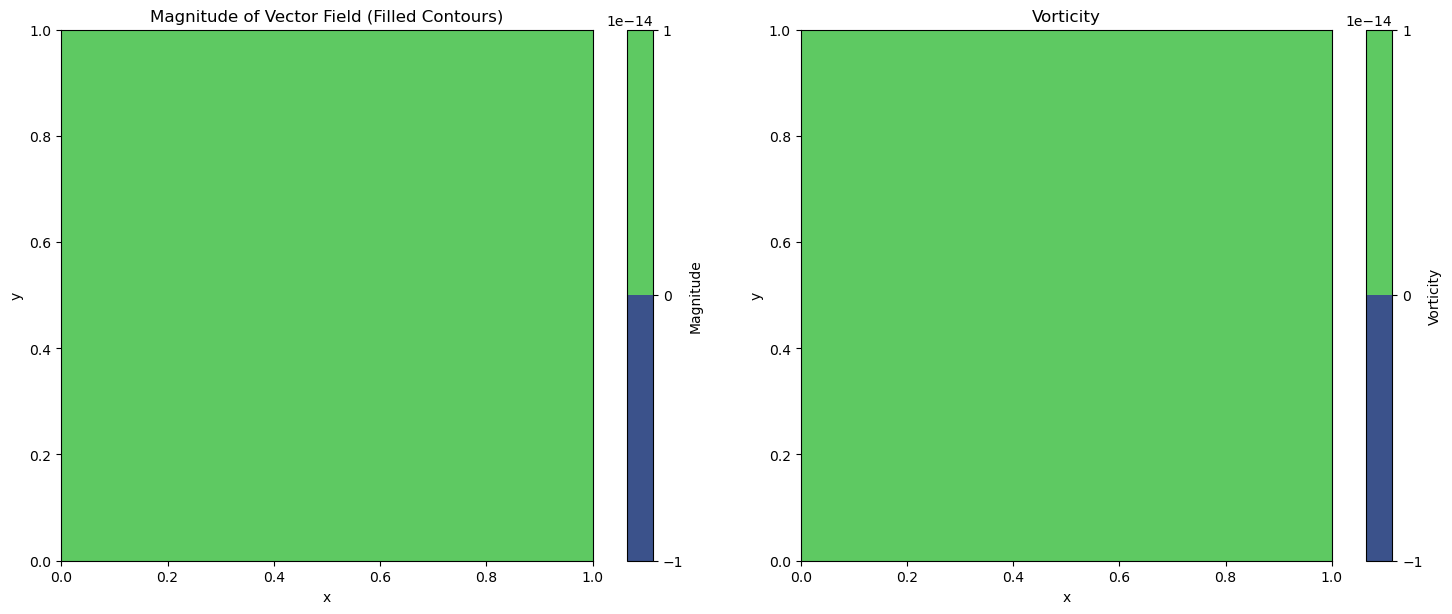

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation
import matplotlib.tri as tri

# Calculate the magnitude of the vector field
function_values_x = phi.getListOfSingleFields()[0].getCoefficientArray()
function_values_y = phi.getListOfSingleFields()[1].getCoefficientArray()
magnitude = np.sqrt(function_values_x**2 + function_values_y**2)

# Extract x and y coordinates from dof_coordinates
dof_coordinates = vectorSpace.tabulate_dof_coordinates()
x_coords = dof_coordinates[:, 0]
y_coords = dof_coordinates[:, 1]

vorticity_values = vorticity.getCoefficientArray()
# Create triangulation for irregular grid
triang = Triangulation(x_coords, y_coords)

# Create the contour plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Filled contour plot
contour_filled = ax1.tricontourf(triang, magnitude, levels=20, cmap='viridis')
ax1.set_title('Magnitude of Vector Field (Filled Contours)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal')
plt.colorbar(contour_filled, ax=ax1, label='Magnitude')

print(magnitude)
print(vorticity_values)
print(np.max(vorticity_values))
print(np.min(vorticity_values))

# Plot 1: Filled contour plot
vorticity_filled = ax2.tricontourf(triang, vorticity_values, levels=20, cmap='viridis')
ax2.set_title('Vorticity')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal')
plt.colorbar(vorticity_filled, ax=ax2, label='Vorticity')

plt.tight_layout()
plt.show()